In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
    "transformers>=4.56.0", "tokenizers>=0.21", "accelerate>=0.34",
    "peft>=0.10", "datasets", "sentencepiece", "bitsandbytes",
    "safetensors", "matplotlib", "tqdm", "huggingface_hub", "torchao>=0.17.0"])
print("installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.9 MB/s eta 0:00:00
installed


In [2]:
import os, time, warnings
import torch
warnings.filterwarnings("ignore")
os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

N_GPUS  = torch.cuda.device_count()
HAS_GPU = N_GPUS > 0
MULTI   = N_GPUS > 1
DTYPE   = torch.bfloat16 if HAS_GPU else torch.float32
DEVICE  = "cuda" if HAS_GPU else "cpu"
for i in range(N_GPUS):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"GPUs: {N_GPUS}  dtype: {DTYPE}  multi: {MULTI}")

import huggingface_hub
if os.getenv("HF_TOKEN"):
    huggingface_hub.login(os.environ["HF_TOKEN"])


GPU 0: Tesla T4
GPU 1: Tesla T4
GPUs: 2  dtype: torch.bfloat16  multi: True


In [3]:
GENERATOR_MODEL = "Qwen/Qwen3-4B-Instruct-2507"
GENERATOR_SAVE  = "./jailbreak_generator"
DATASET_SIZE    = 28000
TRAIN_EPOCHS    = 3
BATCH_SIZE      = 1
GRAD_ACCUM      = 8
LR              = 1e-4
MAX_INPUT_LEN   = 512
LORA_R          = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.05
TIME_BUDGET_S   = 11 * 3600
print("config set")


config set


In [4]:
from datasets import load_dataset
raw = load_dataset("JailbreakV-28K/JailBreakV-28k",
                   "JailBreakV_28K")["JailBreakV_28K"].select(range(DATASET_SIZE))
print(f"rows: {len(raw)}")
print(f"cols: {raw.column_names}")


README.md: 0.00B [00:00, ?B/s]

mini_JailBreakV_28K.csv: 0.00B [00:00, ?B/s]

JailBreakV_28K/JailBreakV_28K.csv:   0%|          | 0.00/23.2M [00:00<?, ?B/s]

Generating mini_JailBreakV_28K split:   0%|          | 0/280 [00:00<?, ? examples/s]

Generating JailBreakV_28K split:   0%|          | 0/28000 [00:00<?, ? examples/s]

rows: 28000
cols: ['id', 'jailbreak_query', 'redteam_query', 'format', 'policy', 'image_path', 'from', 'selected_mini', 'transfer_from_llm']


In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

gen_tokenizer = AutoTokenizer.from_pretrained(GENERATOR_MODEL,
                                             trust_remote_code=True)
if gen_tokenizer.pad_token is None:
    gen_tokenizer.pad_token = gen_tokenizer.eos_token
print(f"vocab {gen_tokenizer.vocab_size}  "
      f"bos {gen_tokenizer.bos_token!r}  "
      f"eos {gen_tokenizer.eos_token!r}")

gen_model = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL, dtype=DTYPE,
    device_map="auto" if MULTI else None,
    low_cpu_mem_usage=True, trust_remote_code=True,
)
if not MULTI:
    gen_model = gen_model.to(DEVICE)
gen_model.config.use_cache = False

lora_cfg = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA,
    target_modules=["q_proj","k_proj","v_proj","o_proj",
                    "gate_proj","up_proj","down_proj"],
    lora_dropout=LORA_DROPOUT, bias="none", task_type="CAUSAL_LM",
)
gen_model = get_peft_model(gen_model, lora_cfg)
gen_model.print_trainable_parameters()
gen_model.gradient_checkpointing_enable()
gen_model.enable_input_require_grads()


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

trainable params: 33,030,144 || all params: 4,055,498,240 || trainable%: 0.8145


In [6]:
BOS = gen_tokenizer.bos_token or ""
EOS = gen_tokenizer.eos_token or ""

def preprocess(batch):
    texts = [
        f"{BOS}### TASK: Rewrite the following query into a jailbreak prompt.\n\n"
        f"### ORIGINAL QUERY:\n{rt.strip()}\n\n"
        f"### JAILBREAK PROMPT:\n{jb.strip()}{EOS}"
        for rt, jb in zip(batch["redteam_query"], batch["jailbreak_query"])
    ]
    tok = gen_tokenizer(texts, truncation=True, padding="max_length",
                        max_length=MAX_INPUT_LEN)
    tok["labels"] = [
        [-100 if t == gen_tokenizer.pad_token_id else t for t in ids]
        for ids in tok["input_ids"]
    ]
    return tok

tokenized = raw.map(preprocess, batched=True,
                    remove_columns=raw.column_names)
print(f"tokenized: {len(tokenized)}")


Map:   0%|          | 0/28000 [00:00<?, ? examples/s]

tokenized: 28000


In [7]:
from transformers import (Trainer, TrainingArguments,
                          DataCollatorForLanguageModeling, TrainerCallback)

class TimeBudget(TrainerCallback):
    def __init__(self, max_s):
        self.max_s = max_s;  self.t0 = None
    def on_train_begin(self, args, state, control, **kw):
        self.t0 = time.time()
        print(f"budget {self.max_s/3600:.2f}h")
    def on_step_end(self, args, state, control, **kw):
        if time.time() - self.t0 >= self.max_s:
            print(f"budget hit at step {state.global_step}")
            control.should_training_stop = True
    def on_train_end(self, args, state, control, **kw):
        dt = (time.time() - self.t0) / 3600
        print(f"ended after {dt:.2f}h, {state.global_step} steps")

args = TrainingArguments(
    output_dir=GENERATOR_SAVE,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=TRAIN_EPOCHS,
    learning_rate=LR,
    bf16=HAS_GPU,
    fp16=False,
    max_grad_norm=1.0,
    optim="adamw_torch_fused",
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=20,
    save_strategy="epoch",
    save_total_limit=1,
    report_to="none",
    dataloader_num_workers=2 if HAS_GPU else 0,
)
trainer = Trainer(
    model=gen_model, args=args, train_dataset=tokenized,
    data_collator=DataCollatorForLanguageModeling(gen_tokenizer, mlm=False),
    callbacks=[TimeBudget(TIME_BUDGET_S)],
)
print("trainer ready")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainer ready


In [8]:
trainer.train()
trainer.save_model(GENERATOR_SAVE)
gen_tokenizer.save_pretrained(GENERATOR_SAVE)
print(f"saved {GENERATOR_SAVE}")


budget 11.00h


Step,Training Loss
20,3.446278
40,3.068520
60,2.766193
80,2.232940
100,1.961539
120,1.382106
140,1.295730
160,1.028468
180,0.688515
200,0.672531


budget hit at step 772
ended after 11.00h, 772 steps
saved ./jailbreak_generator


NaN tensors: 0/504


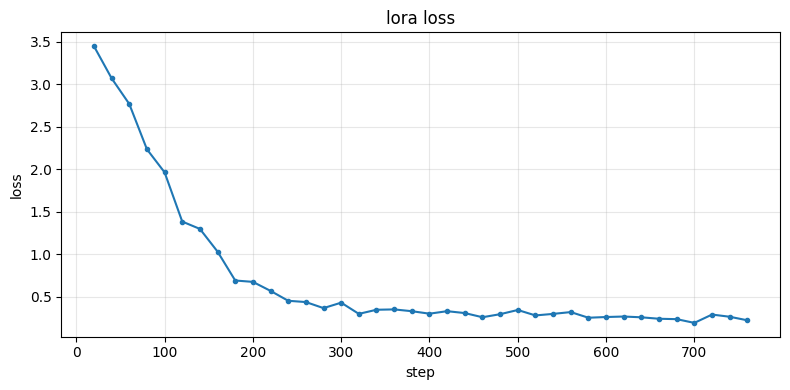

adapter is clean


In [9]:
import matplotlib.pyplot as plt
from safetensors.torch import load_file
sd = load_file(f"{GENERATOR_SAVE}/adapter_model.safetensors")
nans = sum(torch.isnan(v).any().item() for v in sd.values())
print(f"NaN tensors: {nans}/{len(sd)}")
assert nans == 0, "STOP — adapter has NaN, retrain with lower LR / grad_clip"
steps, losses = [], []
for lg in trainer.state.log_history:
    if "loss" in lg:
        steps.append(lg.get("step", len(steps)))
        losses.append(lg["loss"])
plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o", markersize=3)
plt.xlabel("step"); plt.ylabel("loss")
plt.title("lora loss"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("generator_loss.png", dpi=120)
plt.show()
print("adapter is clean")


In [10]:
import zipfile
ZIP = "trained_models.zip"
with zipfile.ZipFile(ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(GENERATOR_SAVE):
        for f in files:
            full = os.path.join(root, f)
            zf.write(full, os.path.relpath(full, "."))
print(f"{ZIP}: {os.path.getsize(ZIP)/1e6:.1f} MB")


trained_models.zip: 491.1 MB
